# DS 3000 - Assignment 5
**Student Name**: Gauri Rajesh

**Date**: 6/7/25


### Submission Instructions
Submit this `ipynb` file to canvas.

The `ipynb` format stores outputs from the last time you ran the notebook.  (When you open a notebook it has the figures and outputs of the last time you ran it too).  To ensure that your submitted `ipynb` file represents your latest code, make sure to give a fresh run `Kernel > Restart & Run All` just before uploading the `ipynb` file to Canvas.

### Academic Integrity

**Writing your homework is an individual effort.**  You may discuss general python problems with other students but under no circumstances should you observe another student's code which was written for this assignment, from this year or past years.  Pop into office hours or DM us in MS Teams if you have a specific question about your work or if you would like another pair of eyes or talk through your code.

Don't forget to cite websites which helped you solve a problem in a unique way.  You can do this in markdown near the code or with a simple one-line comment. You do not need to cite the official python documentation.

**Documentation / style counts for credit**  Please refer to the Pep-8 style, to improve the readability and consistency of your Python code. For more information, read the following article [How to Write Beautiful Python Code With PEP 8](https://realpython.com/python-pep8/) or ask your TA's for tips.

**NOTE:<span style='color:red'> Write python expressions to answer ALL questions below and ensure that you use the `print()` function to display the output.</span>** Each question should be answered in a new code cell. For example, your solution for question 1.1 should be in a different code cell from your solution for question 1.2.

## Question 1: Load Data

TODO: Load the data directly from the URL into a DataFrame.


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor

# load dataset
df = pd.read_csv("https://drive.google.com/uc?id=145n4_o1g5ZMrnV_DZt8tR9rjZLlJvU5K")

# inspect head
df.head(10)

,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0
2,3,128,279.0,0,28.0,64.0,115.0,1.0
3,4,123,NaN,0,36.0,69.0,190.0,0.0
4,5,108,282.0,0,23.0,67.0,125.0,1.0
5,6,136,286.0,0,25.0,62.0,93.0,0.0
6,7,138,244.0,0,33.0,62.0,178.0,0.0
7,8,132,245.0,0,23.0,65.0,140.0,0.0
8,9,120,289.0,0,25.0,62.0,125.0,0.0
9,10,143,299.0,0,30.0,66.0,136.0,1.0


## Question 2: Data Prep & EDA
Prepare the data for analysis. Ensure that you address the following:
* Perform EDA using the dataset to demonstrate patterns.
<br></br>
* Handle any missing data and invalid data. Justify your approach.
<br></br>
* Plot a histogram of the birth weight and explain the overall distribution. 


In [2]:
# inspect dimensions
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns.")

There are 1236 rows and 8 columns.


In [3]:
# inspect data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   case       1236 non-null   int64  
 1   bwt        1236 non-null   int64  
 2   gestation  1223 non-null   float64
 3   parity     1236 non-null   int64  
 4   age        1234 non-null   float64
 5   height     1214 non-null   float64
 6   weight     1200 non-null   float64
 7   smoke      1226 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 77.4 KB


Length of gestation can be converted to integers since it is in terms of days.  Mother's age can also be converted to integers since it is in terms of years.  Smoke can also be converted to integers since it is a binary indicator that can only be 0 or 1.

In [4]:
# convert to appropriate data types
df['gestation'] = df['gestation'].astype('Int64')
df['age'] = df['age'].astype('Int64')
df['smoke'] = df['smoke'].astype('Int64')

# verify changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   case       1236 non-null   int64  
 1   bwt        1236 non-null   int64  
 2   gestation  1223 non-null   Int64  
 3   parity     1236 non-null   int64  
 4   age        1234 non-null   Int64  
 5   height     1214 non-null   float64
 6   weight     1200 non-null   float64
 7   smoke      1226 non-null   Int64  
dtypes: Int64(3), float64(2), int64(3)
memory usage: 81.0 KB


In [5]:
# handle missing values

# display percentage of missing values for each feature
df.isnull().mean()*100

case         0.000000
bwt          0.000000
gestation    1.051780
parity       0.000000
age          0.161812
height       1.779935
weight       2.912621
smoke        0.809061
dtype: float64

In [6]:
# distribution of missing values in rows
df.isnull().sum(axis=1).sort_values(ascending=False).value_counts()

0    1174
1      43
2      17
3       2
Name: count, dtype: int64

Based on the distribution of missing values in the dataset, the features with missing values are gestation, age, height, and weight.  Out of 1236 entries, 62 entries contain missing values.  Since gestation, age, height, and weight may affect the analysis of birth weight, rows with missing values will be removed.  Deletion is also a suitable approach since a majority of the dataset, specifically 1175 rows, will still be available for analysis.

In [7]:
# remove rows with null values
df = df.dropna()

# verify changes
df.isnull().sum(axis=1).sort_values(ascending=False).value_counts()

0    1174
Name: count, dtype: int64

In [8]:
# check for invalid data

# determine if binary indicators parity or smoke contain values
# aside from 0 and 1

# check for invalid parity values
df['parity'].value_counts()

parity
0    866
1    308
Name: count, dtype: int64

In [9]:
# check for invalid smoke values
df['smoke'].value_counts()

smoke
0    715
1    459
Name: count, dtype: Int64

Based on this analysis, binary indicators smoke and parity do not contain invalid values aside from 0 and 1.

In [10]:
# check for negative values in bwt, gestation, age, height
# and weight

negativeBwtCount = (df['bwt'] < 0).sum()
negativeGestCount = (df['gestation'] < 0).sum()
negativeAgeCount = (df['age'] < 0).sum()
negativeHeightCount = (df['height'] < 0).sum()
negativeWeightCount = (df['weight'] < 0).sum()

print(f"Negative bwt count: {negativeBwtCount} \n"
      + f"Negative gestation count: {negativeGestCount} \n"
      + f"Negative age count: {negativeAgeCount} \n"
      + f"Negative height count: {negativeHeightCount} \n"
      + f"Negative weight count: {negativeWeightCount} \n")

Negative bwt count: 0 
Negative gestation count: 0 
Negative age count: 0 
Negative height count: 0 
Negative weight count: 0 



Based on this analysis, bwt, gestation, height, and weight do not contain any invalid negative values.

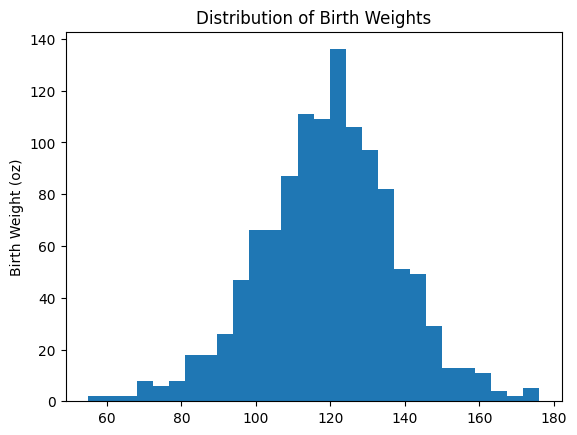

In [11]:
# plot histogram of birth weight
plt.hist(df['bwt'], bins='auto')
plt.title('Distribution of Birth Weights')
plt.ylabel('Birth Weight (oz)')
plt.ylabel
plt.show()

Based on the histogram, the distribution of birth weights resembles a bell shape, indicating a normal distribution and that the mean, median, and mode are likely close.  The peak or mode value for birth weights is about 120 oz.  Most birth weights are between 90 oz and 150 oz.  There does not appear to be any significant skew or outliers based on the histogram.  

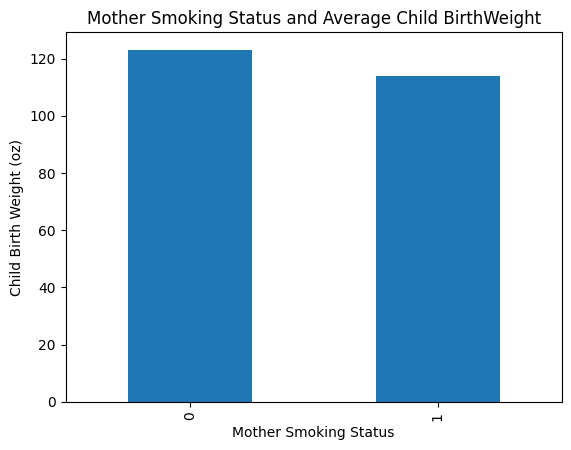

smoke
0    123.085315
1    113.819172
Name: bwt, dtype: float64

In [12]:
# explore relationship between birthweight and binary indicators
# smoking and parity

# explore relationship between smoking and birthweight
smoking_and_bwt_df = df.groupby('smoke')['bwt'].mean()
smoking_and_bwt_df.plot(kind='bar')
plt.title('Mother Smoking Status and Average Child BirthWeight')
plt.ylabel('Child Birth Weight (oz)')
plt.xlabel('Mother Smoking Status')
plt.show()
smoking_and_bwt_df.head()

Based on this analysis, the average weight of babies whose mothers smoked was about 9.2 oz less than the average weight of babies whose mothers did not smoke.  The average weight of babies whose mothers did not smoke was 123.09 oz whereas it was 113.82 oz for babies whose mothers did smoke.

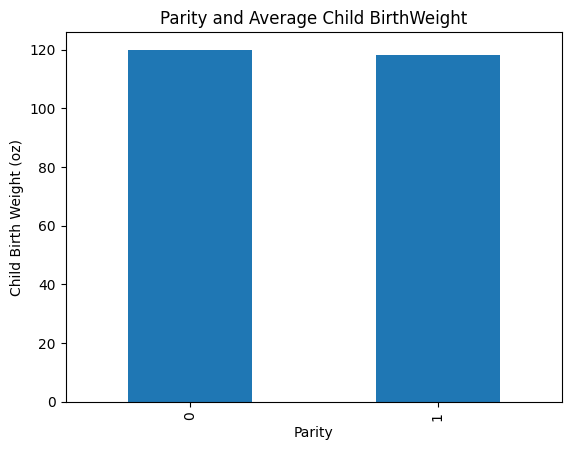

parity
0    119.942263
1    118.113636
Name: bwt, dtype: float64

In [13]:
# explore relationship between parity and birthweight
parity_and_bwt = df.groupby('parity')['bwt'].mean()
parity_and_bwt.plot(kind='bar')
plt.title('Parity and Average Child BirthWeight')
plt.ylabel('Child Birth Weight (oz)')
plt.xlabel('Parity')
plt.show()
parity_and_bwt.head()

Based on this analysis, the average weight of babies from first time pregnancies was about 119.94 oz whereas the average weight of babies not from first time pregancies was 118.11 oz.  There does not appear to be a clear relationship between parity and birth weight since there is only a slight difference in average weights.

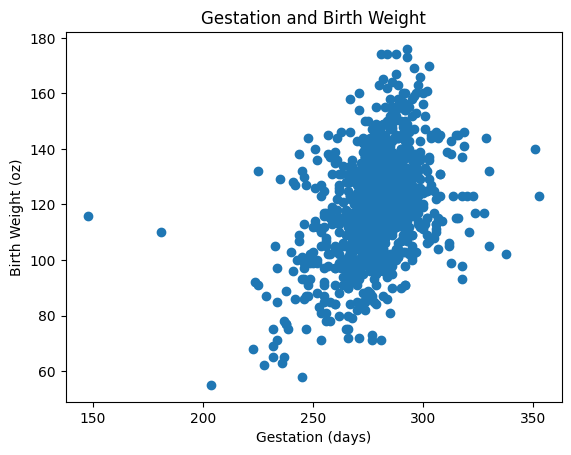

In [14]:
# explore relationship between gestation and birthweight
plt.scatter(df['gestation'], df['bwt'])
plt.title('Gestation and Birth Weight')
plt.xlabel('Gestation (days)')
plt.ylabel('Birth Weight (oz)')
plt.show()

Based on this scatterplot, gestation in days ranges from 150 to 350 days.  The data appears to cluster tightly between 250 and 300 days.  The birth weight in this cluster ranges from 80 oz to 180 oz.  There are a few outliers in the dataset with the gestation period less than 200 days or greater than 325 days.  There appears to be a positive correlation between number of gestation days and birth weight.  

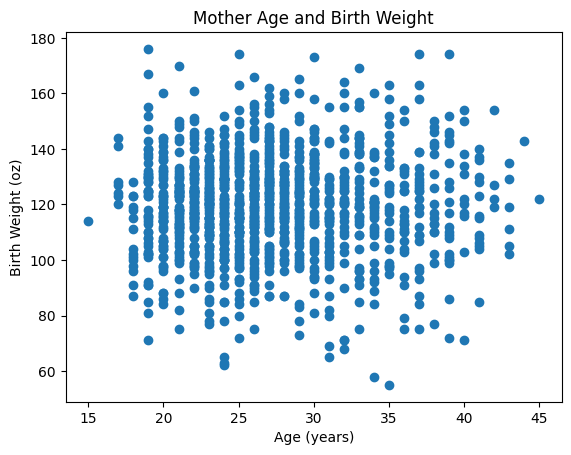

In [15]:
# explore relationship between mother's age and birthweight
plt.scatter(df['age'], df['bwt'])
plt.title('Mother Age and Birth Weight')
plt.xlabel('Age (years)')
plt.ylabel('Birth Weight (oz)')
plt.show()

Based on this scatterplot, the age of mothers ranges between 15 years and 43 years.  The dataset clusters between 20 years and 35 years, indicating that most mothers fall in this age group.  The birth weight ranges from about 30 oz to just under 180 oz, with most clustering between 90 oz and 150 oz.  The birth weight appears to be randomly scattered across ages, indicating that mother's age is likely not a strong predictor of birth weight.

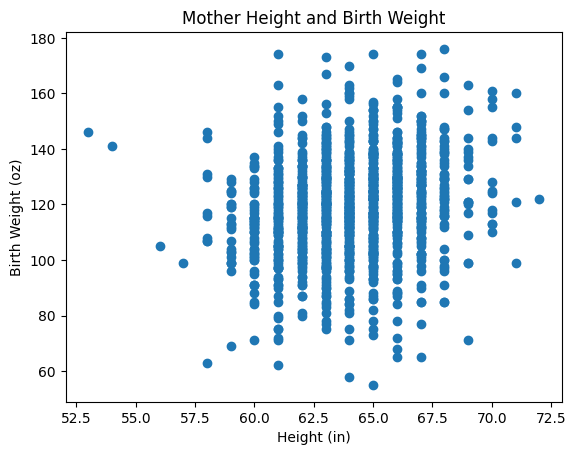

In [16]:
# explore relationship between height and birth weight
plt.scatter(df['height'], df['bwt'])
plt.title('Mother Height and Birth Weight')
plt.xlabel('Height (in)')
plt.ylabel('Birth Weight (oz)')
plt.show()

Based on this scatterplot, the height of mothers ranges from about 53 inches to 72 inches.  The heights of mothers appear to cluster between 58 inches and 68 inches.  The birthweight appears to be randomly scattered across heights, indicating that height of the mother is not a strong indicator of birth weight.

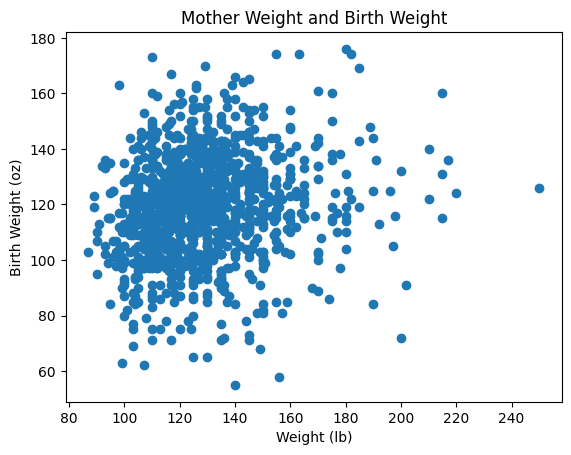

In [17]:
# explore relationship between weight and birth weight
plt.scatter(df['weight'], df['bwt'])
plt.title('Mother Weight and Birth Weight')
plt.xlabel('Weight (lb)')
plt.ylabel('Birth Weight (oz)')
plt.show()

Based on this scatterplot, the weight of mothers ranges from 85 lbs to about 255 lbs.  The weight of mothers clusters between 85 lbs and 160 lbs, indicating this is the most common weight range of mothers.  While there is a slight positive correlation, there does not appear to be a significant relationship between mother's weight and birth weight of the child.

## Question 3: Feature Selection
Demonstrate which features are useful to build the model. Briefly explain the reason for the features that you selected.
<br></br>
Note: You can explore correlations, test hypothesis and/or other techniques. Remember that Data Science relies heavily on experimentation. Therefore, you are encouraged to experiment with your data.
* Tip #1: ensure that you carefully consider each feature and share the pros and cons of your decisions.
<br></br>
* Tip #2: you are predicting the birth weight, therefore it should not be one of your explanatory variables.

Based on the EDA, the mother's smoking status and the number of gestation days were selected as feature variables.  Number of gestation days was selected as there appears to be a slight positive correlation between mother's weight and birth weight of the child.  Mother's smoking status was also selected as babies born to mothers who smoked during pregnancy had lower average birth weights by about 9.2 oz.  While smoking and gestation days appeared to be the strongest indicators of birth weight, one disadvantage of excluding additional features could be underfitting and information loss.  However, the data appeared to be more randomly scattered for the other variables, meaning that they may not be strong indicators of birth weight.      

## Question 4: Data Partitioning
Partition the prepared data into train/test sets, ensure that your partitions are reproducible. Encode any categorical variables in your training set. Then, use the appropriate approach to encode your test set.

In [18]:
# get input features and target
X = df[['smoke', 'gestation']]
y = df['bwt']

# split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

None of the feature variables need to be encoded since the only binary indicator is smoke, and this has already been set to either 0 or 1 in the dataset.  Gestation is a continuous numerical value so it does not need to be encoded.

## Question 5: Model Development
Using the Random Forest algorithm, build a machine learning model that predicts the birth weight.
Think about the following: Are you performing classification or regression? Ensure that you choose the appropriate Random Forest Classifier/Regressor from scikit-learn.

I am performing regression analysis because I am attempting to predict a continuous, numerical target variable.  Birth weight is not a categorical variable.

In [19]:
# create and train random forest model
rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=0)

## Question 6: Model Evaluation
Evaluate the predictions from your model and comment on the results. Ensure that you choose the appropriate metric to evaluate the model and round your calculations to two decimal places. Remember that we evaluate models differently depending on the task, i.e. classification or regression.

In [20]:
# make predictions using random forest model
y_pred = rf.predict(X_test)

# evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# display results
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error: 296.13
R² Score: 0.1430


Based on the mean squared error, the predicted values differ by about square root of 296.13 oz or 17.21 oz on average.  Since this is just over 1 lb and the weight of babies clusters between 90 oz or 5.63 lbs and 150 oz or 9.38lbs, this is a significant difference.  The R2 score highlights that the model is only able to explain about 14.3% of variation in birth weights.  Therefore, a majority of variation in birth weights cannot be explained by the feature variables.

## Question 7: Model Tuning
What are your thoughts on the model's prediction capability? Did it do a good job of predicting the birth weight?
<br></br>
Note: it is okay if your first version of the model is not the best. However, there are strategies that we can use to improve it, such as tuning.
<br></br>
Tune the model: you can control the number of trees in your forest using the n_estimators parameter. Refer to the sample code from the lecture and also view the documentation**Links to an external site. to learn more about this algorithm and its parameters. Try at least five different values for the n_estimators parameter to determine if the model improved. 
<br></br>
Show all your steps to create, evaluate and tune each version of the model.
Indicate which model performed the best.

Since a regression analysis was performed, the R2 score and mean squared error were used to evaluate the model's prediction capability.  Based on these scores, the model did not effectively predict birth weight.  

In [21]:
# create and train random forest model with n estimators = 500
rf = RandomForestRegressor(n_estimators=500, random_state=0)
rf.fit(X_train, y_train)

# make predictions using random forest model
y_pred = rf.predict(X_test)

# evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# display results
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error: 295.30
R² Score: 0.1453


In [22]:
# create and train random forest model with n estimators = 1000
rf = RandomForestRegressor(n_estimators=1000, random_state=0)
rf.fit(X_train, y_train)

# make predictions using random forest model
y_pred = rf.predict(X_test)

# evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# display results
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error: 295.16
R² Score: 0.1457


In [23]:
# create and train random forest model with n estimators = 2000
rf = RandomForestRegressor(n_estimators=2000, random_state=0)
rf.fit(X_train, y_train)

# make predictions using random forest model
y_pred = rf.predict(X_test)

# evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# display results
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error: 294.97
R² Score: 0.1463


In [24]:
# create and train random forest model with n estimators = 5000
rf = RandomForestRegressor(n_estimators=5000, random_state=0)
rf.fit(X_train, y_train)

# make predictions using random forest model
y_pred = rf.predict(X_test)

# evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# display results
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error: 294.90
R² Score: 0.1465


In [25]:
# create and train random forest model with n estimators = 10000
rf = RandomForestRegressor(n_estimators=10000, random_state=0)
rf.fit(X_train, y_train)

# make predictions using random forest model
y_pred = rf.predict(X_test)

# evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# display results
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error: 294.98
R² Score: 0.1463


The model with 5000 decision trees performed slightly better than the other random forest models with a mean squared error of 294.9 and R2 score of 14.65%.  However, these scores did not change significantly when changing the number of decision number trees to 500, 1000, 2000, 5000, and 10000.  Therefore, the feature variables selected are likely not strong indicators of birth weight.

## Extra Credit
The Random forest has a method that returns the importance of each feature in your model. Review the documentation to learn about feature importance. After which, write the appropriate code that demonstrates which features were the most important when making the predictions. Visualize the feature importance using the best model and explain the results.

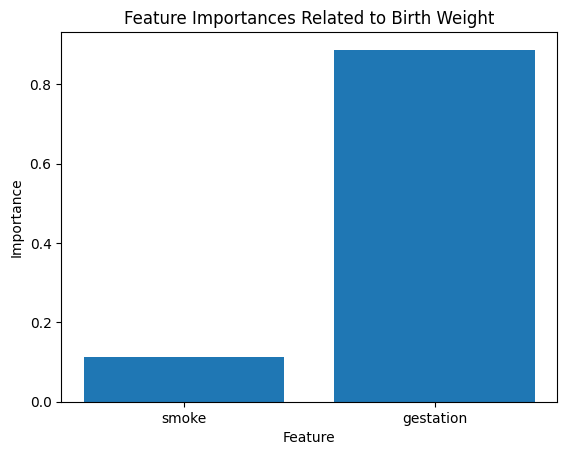

In [26]:
# determine importances of features
importances = rf.feature_importances_
features = X.columns
plt.bar(features, importances)
plt.title('Feature Importances Related to Birth Weight')
plt.xlabel("Feature")
plt.ylabel('Importance')
plt.show()

Based on this analysis, gestation was a stronger indicator of birth weight than smoking status of the mother as it scored over 0.8 while smoke scored about 0.1.  While the random forest model did not demonstrate a high accuracy, the bar graph demonstrates that gestation mainly contributed to the model's predictive ability.  

## Question 8: Model Development with K-NN algorithm
Perform steps 5-7 using the k-nn algorithm. Perform model tuning using at least 5 different values of k. Show all your steps to create, evaluate and tune each version of the model. 
Indicate which model performed the best.

In [27]:
# create and train model using k-nn algorithm
X = df[['gestation', 'smoke']]
y = df['bwt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=7)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsRegressor()

In [28]:
# predict values for test set
y_pred = knn.predict(X_test)

# evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# display results
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error: 324.22
R² Score: 0.0616


Based on the mean squared error and R2 score, the knn model with 5 neighbors was not able to accurately predict the birth weights of newborns.  The predicted values differ by about square root of 324.22 oz or about 18 oz.  This is a significant difference as it is slightly over 1 lb.  The low R2 score also indicates that the model is unable to account for a majority of variation in the dataset.

In [29]:
# create and train model with 50 neighbors
knn = KNeighborsRegressor(n_neighbors=50)
knn.fit(X_train, y_train)

# predict values for test set
y_pred = knn.predict(X_test)

# evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# display results
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error: 283.40
R² Score: 0.1798


In [30]:
# create and train model with 100 neighbors
knn = KNeighborsRegressor(n_neighbors=100)
knn.fit(X_train, y_train)

# predict values for test set
y_pred = knn.predict(X_test)

# evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# display results
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error: 285.88
R² Score: 0.1726


In [31]:
# create and train model with 500 neighbors
knn = KNeighborsRegressor(n_neighbors=500)
knn.fit(X_train, y_train)

# predict values for test set
y_pred = knn.predict(X_test)

# evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# display results
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error: 310.03
R² Score: 0.1027


In [32]:
# create and train model with 500 neighbors
knn = KNeighborsRegressor(n_neighbors=20)
knn.fit(X_train, y_train)

# predict values for test set
y_pred = knn.predict(X_test)

# evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# display results
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error: 293.77
R² Score: 0.1498


In [33]:
# create and train model with 500 neighbors
knn = KNeighborsRegressor(n_neighbors=80)
knn.fit(X_train, y_train)

# predict values for test set
y_pred = knn.predict(X_test)

# evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# display results
print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error: 286.19
R² Score: 0.1717


Based on this analysis, the knn model with the greatest accuracy had 50 neighbors.  This model had a mean squared error of 283.40, indicating that the predictions tend to differ by about 16.83 oz.  The R2 score indicates that the model accounts for about 17.98% of variation in the dataset.

**Overall Analysis**
<br></br>
Based on this analysis, the KNN algorithm with 50 neighbors is likely more suitable to predict birthweight than RandomForest as it had a greater R2 score and lower Mean Squared Error.  However, the difference in predictive capabilities between the two models was not significant and both of them demonstrated poor predictive capabilities.

## Helpful resources 
Don't forget to cite websites which helped you solve a problem in a unique way.  You can do this in markdown near the code or with a simple one-line comment inside the code cell, or you can list them below. 

You do not need to cite the official python documentation.
